In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
#load csv file from github
df = pd.read_csv('https://raw.githubusercontent.com/Leri2025/Lee/main/data/raw/Avocado.csv')
df.head()

,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,BaltimoreWashington


In [3]:
#Number of rows and columns
df.shape


(53415, 12)

In [4]:
#check data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53415 entries, 0 to 53414
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          53415 non-null  object 
 1   AveragePrice  53415 non-null  float64
 2   TotalVolume   53415 non-null  float64
 3   plu4046       53415 non-null  float64
 4   plu4225       53415 non-null  float64
 5   plu4770       53415 non-null  float64
 6   TotalBags     53415 non-null  float64
 7   SmallBags     41025 non-null  float64
 8   LargeBags     41025 non-null  float64
 9   XLargeBags    41025 non-null  float64
 10  type          53415 non-null  object 
 11  region        53415 non-null  object 
dtypes: float64(9), object(3)
memory usage: 4.9+ MB


In [6]:
#Descriptive Statistics for numerical values
df.describe()

,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags
count,53415.000000,5.341500e+04,5.341500e+04,5.341500e+04,5.341500e+04,5.341500e+04,4.102500e+04,4.102500e+04,41025.000000
mean,1.428910,8.694474e+05,2.982707e+05,2.222170e+05,2.053195e+04,2.175083e+05,1.039222e+05,2.331316e+04,2731.811796
std,0.393116,3.545274e+06,1.307669e+06,9.554624e+05,1.040977e+05,8.676947e+05,5.692608e+05,1.496622e+05,22589.096454
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.119091,1.626465e+04,6.947250e+02,2.120800e+03,0.000000e+00,7.846520e+03,0.000000e+00,0.000000e+00,0.000000
50%,1.400000,1.203525e+05,1.458058e+04,1.751663e+04,9.005000e+01,3.695310e+04,6.945800e+02,0.000000e+00,0.000000
75%,1.690000,4.542380e+05,1.287924e+05,9.351560e+04,3.599735e+03,1.110146e+05,3.795298e+04,2.814920e+03,0.000000
max,3.440830,6.103446e+07,2.544720e+07,2.047057e+07,2.860025e+06,1.629830e+07,1.256716e+07,4.324231e+06,679586.800000


In [5]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Date                0
AveragePrice        0
TotalVolume         0
plu4046             0
plu4225             0
plu4770             0
TotalBags           0
SmallBags       12390
LargeBags       12390
XLargeBags      12390
type                0
region              0
dtype: int64


In [6]:
#Change date format to date from object
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,Albany
78,2015-01-04,1.13,109215.00,48285.15,37562.78,34.10,23332.97,21582.97,1750.00,0.0,conventional,Roanoke
77,2015-01-04,1.54,4212.16,238.48,1678.83,372.55,1922.30,1570.28,352.02,0.0,organic,RichmondNorfolk
76,2015-01-04,1.13,182697.97,56293.75,80396.09,9762.41,36245.72,31778.36,4467.36,0.0,conventional,RichmondNorfolk
75,2015-01-04,2.01,3397.00,58.22,1493.90,772.21,1072.67,993.94,78.73,0.0,organic,RaleighGreensboro


In [7]:
# understand text columns
print("Unique avocado types:", df['type'].unique())
print("Unique regions:", df['region'].nunique())

Unique avocado types: ['conventional' 'organic']
Unique regions: 60


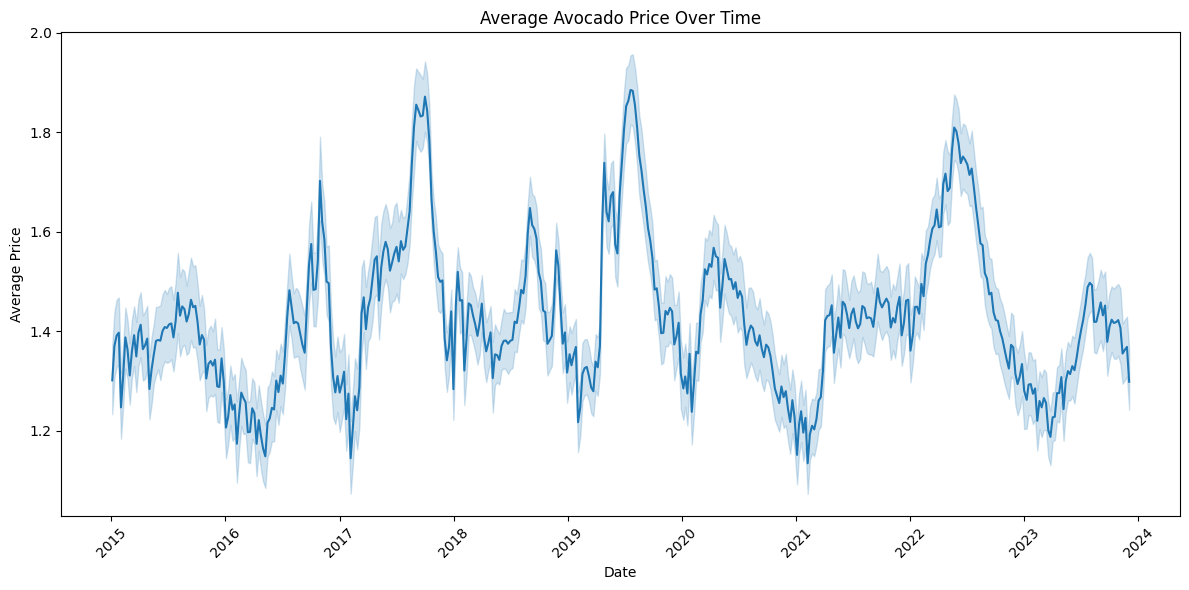

In [8]:
#Plot line graph to see price of Avocado over time on average
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='AveragePrice', data=df)
plt.title('Average Avocado Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

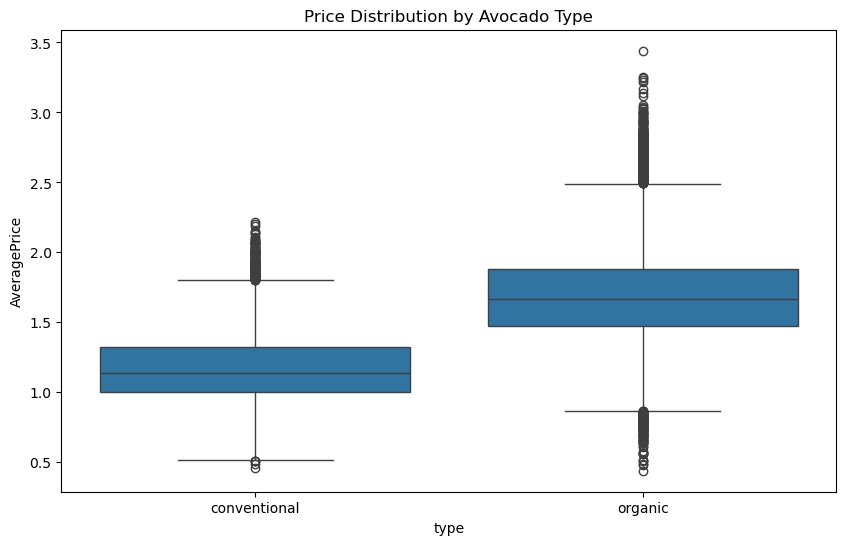

In [16]:
#Distribution by Avocado type
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='AveragePrice', data=df)
plt.title('Price Distribution by Avocado Type')
plt.show()

In [9]:
#Show different regions
regions = df['region'].unique()
print(f"Number of unique regions: {len(regions)}")
print("Regions:")
print(regions)

Number of unique regions: 60
Regions:
['Albany' 'Roanoke' 'RichmondNorfolk' 'RaleighGreensboro' 'Portland'
 'Plains' 'Pittsburgh' 'PhoenixTucson' 'Philadelphia' 'Orlando'
 'NorthernNewEngland' 'Northeast' 'NewYork' 'Sacramento' 'SanDiego'
 'WestTexNewMexico' 'West' 'TotalUS' 'Tampa' 'Syracuse' 'StLouis'
 'NewOrleans' 'Spokane' 'Southeast' 'SouthCentral' 'SouthCarolina'
 'Seattle' 'SanFrancisco' 'Nashville' 'Denver' 'DallasFtWorth' 'Columbus'
 'CincinnatiDayton' 'Chicago' 'Charlotte' 'California' 'BuffaloRochester'
 'Boston' 'Boise' 'BaltimoreWashington' 'Atlanta' 'Detroit' 'LosAngeles'
 'Midsouth' 'Miami' 'Louisville' 'LasVegas' 'Jacksonville' 'Indianapolis'
 'GrandRapids' 'GreatLakes' 'HarrisburgScranton' 'HartfordSpringfield'
 'Houston' 'Providence' 'PeoriaSpringfield' 'Wichita' 'Toledo'
 'BirminghamMontgomery' 'MiamiFtLauderdale']


In [22]:
grouped_counts = df.groupby(['region', 'type']).size().reset_index(name='count')
grouped_counts.head()

,region,type,count
0,Albany,conventional,466
1,Albany,organic,466
2,Atlanta,conventional,466
3,Atlanta,organic,466
4,BaltimoreWashington,conventional,466


              AveragePrice  TotalVolume   plu4046   plu4225   plu4770  \
AveragePrice      1.000000    -0.179153 -0.184299 -0.155367 -0.143928   
TotalVolume      -0.179153     1.000000  0.966413  0.930966  0.817264   
plu4046          -0.184299     0.966413  1.000000  0.880644  0.828545   
plu4225          -0.155367     0.930966  0.880644  1.000000  0.803806   
plu4770          -0.143928     0.817264  0.828545  0.803806  1.000000   
TotalBags        -0.166318     0.965620  0.920839  0.893413  0.775465   
SmallBags        -0.137005     0.707320  0.673314  0.714187  0.639742   
LargeBags        -0.127858     0.587231  0.590021  0.650030  0.585541   
XLargeBags       -0.103314     0.540959  0.475127  0.446047  0.429754   

              TotalBags  SmallBags  LargeBags  XLargeBags  
AveragePrice  -0.166318  -0.137005  -0.127858   -0.103314  
TotalVolume    0.965620   0.707320   0.587231    0.540959  
plu4046        0.920839   0.673314   0.590021    0.475127  
plu4225        0.893413   0.7

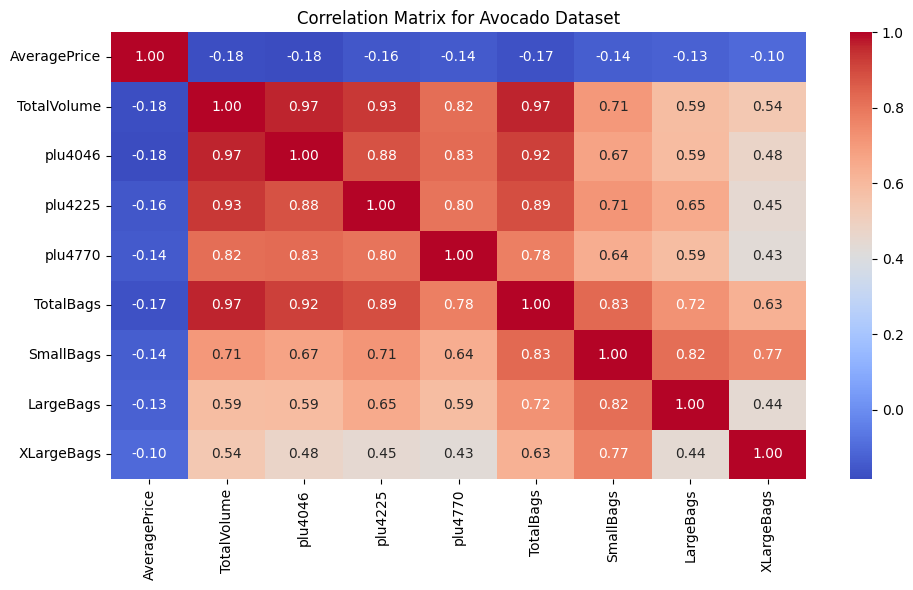

In [10]:
#Correlation with Numeric variables
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Avocado Dataset')
plt.tight_layout()
plt.show()

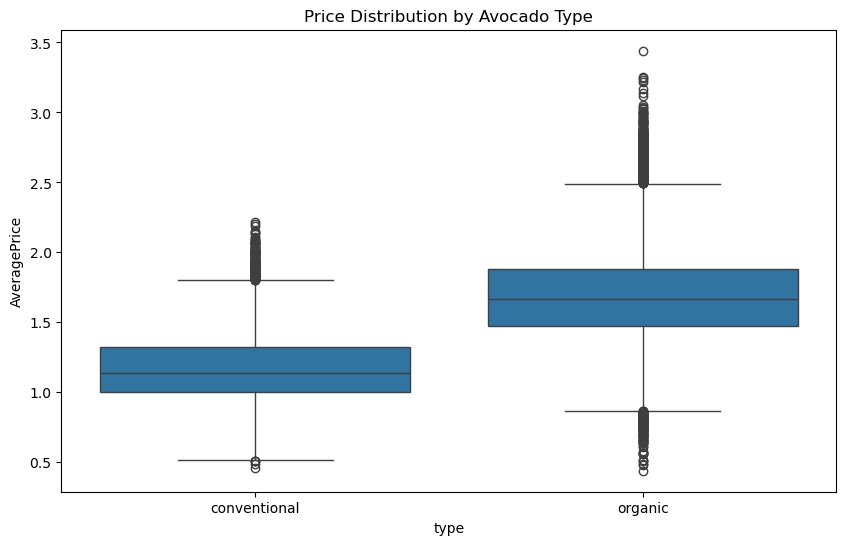

In [32]:
# ===  Feature Engineering ===
df = df.copy()
df = df.sort_values("Date")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Check available columns
print("Columns in df:", df.columns.tolist())

# Add month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Lag features (previous week's price and volume if available)
df['Price_Lag1'] = df['AveragePrice'].shift(1)

if 'TotalVolume' in df.columns:   # <- correct name
    df['Volume_Lag1'] = df['TotalVolume'].shift(1)
    df['Volume_Rolling3'] = df['TotalVolume'].rolling(window=3).mean()
else:
    print("⚠️ No TotalVolume column found, skipping volume features")
    df['Volume_Lag1'] = np.nan
    df['Volume_Rolling3'] = np.nan

# Rolling averages for price
df['Price_Rolling3'] = df['AveragePrice'].rolling(window=3).mean()

df = df.dropna()  # drop rows with NA from lags/rolling

Columns in df: ['Date', 'AveragePrice', 'TotalVolume', 'plu4046', 'plu4225', 'plu4770', 'TotalBags', 'SmallBags', 'LargeBags', 'XLargeBags', 'type', 'region']


In [33]:
# === 2. Define Features & Target ===
feature_cols = ['Price_Lag1','Price_Rolling3','Month','Year']
if 'TotalVolume' in df.columns:
    feature_cols += ['Volume_Lag1','Volume_Rolling3']

X = df[feature_cols]
y = df['AveragePrice']

# Train-test split: last 20% for testing
split_index = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [42]:
# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#Ridge Regression 

ridge = Ridge(alpha=1.0, random_state=42)  # you can tune alpha later
ridge.fit(X_train, y_train)



y_pred_ridge = ridge.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression MSE: {mse}")
print(f"Ridge Regression R^2: {r2}")

Ridge Regression MSE: 0.047759473413317134
Ridge Regression R^2: 0.6614204094394752


In [43]:
def evaluate(y_true, y_pred, Avoprices):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  
    r2 = r2_score(y_true, y_pred)  # R-squared
    print(f"{Avoprices} -> RMSE: {rmse:.4f}, R²: {r2:.4f}")
  

In [44]:

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test,y_pred_ridge,"Ridge Regression")

Linear Regression -> RMSE: 0.2185, R²: 0.6614
Random Forest -> RMSE: 0.2170, R²: 0.6660
Ridge Regression -> RMSE: 0.2185, R²: 0.6614


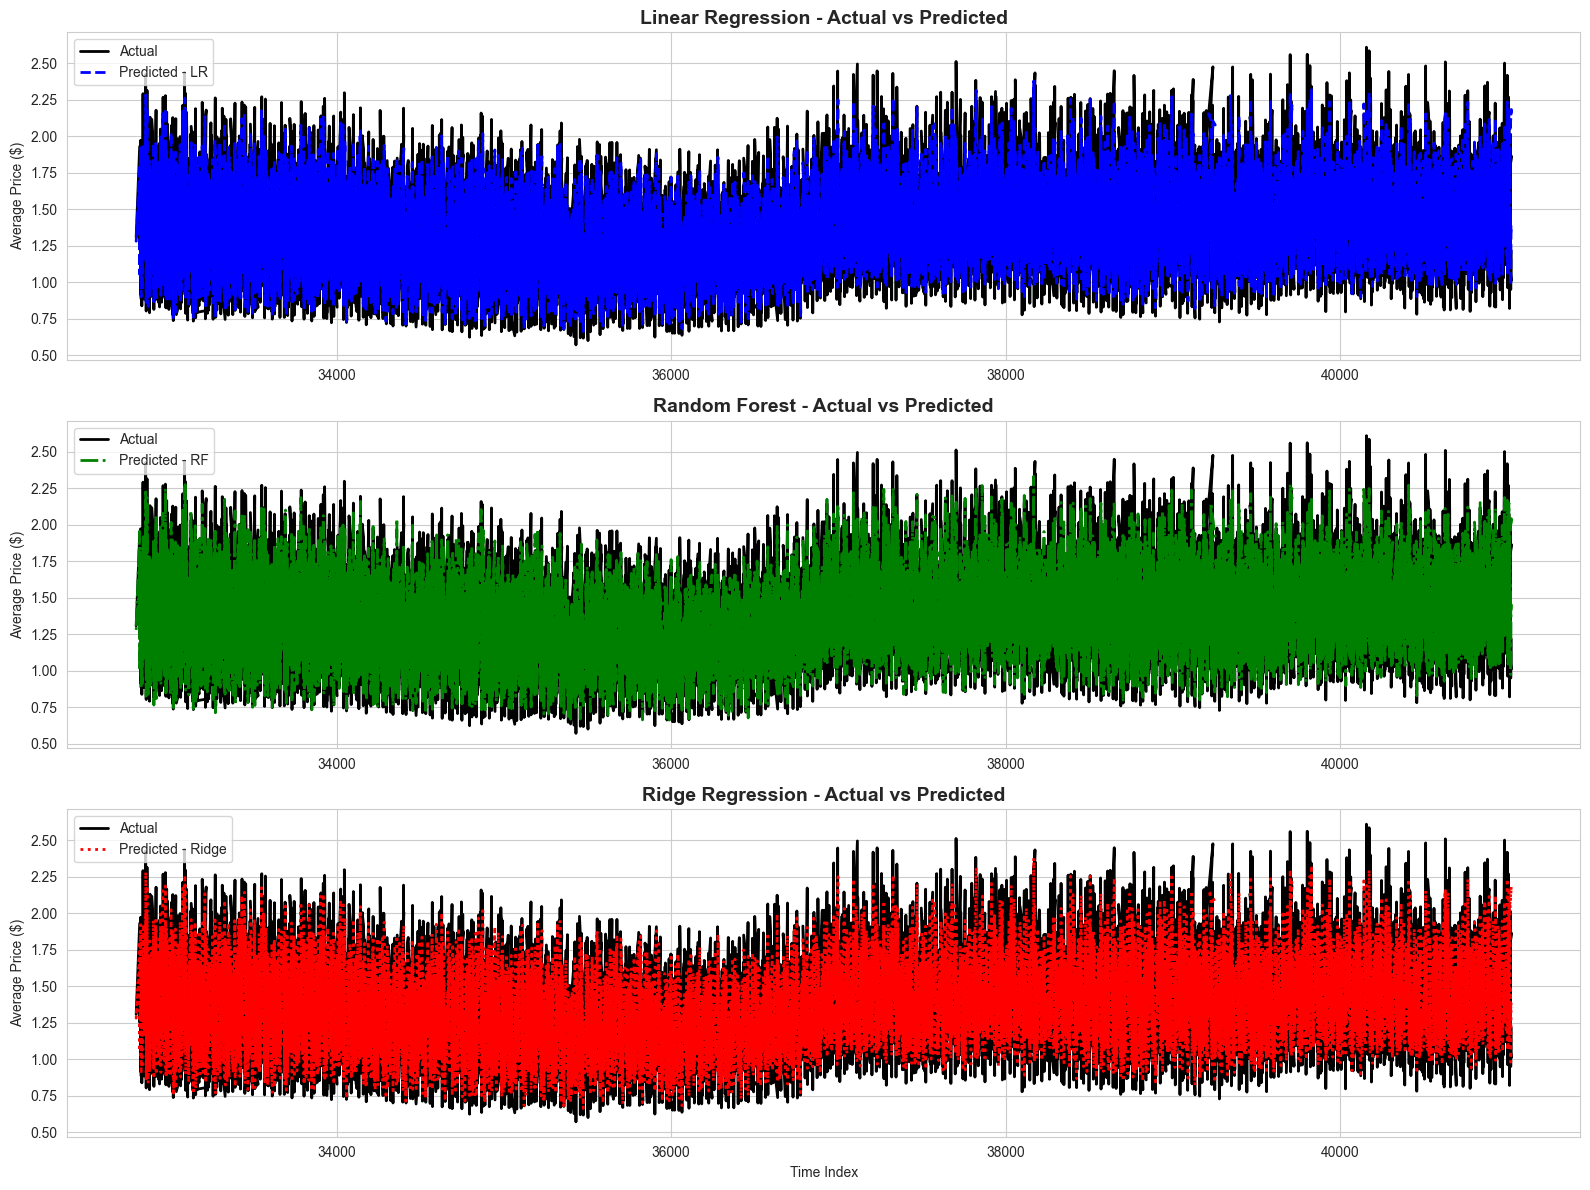

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use Seaborn style for a clean look
sns.set_style("whitegrid")

plt.figure(figsize=(16, 12))

# Linear Regression
plt.subplot(3, 1, 1)  # 3 rows, 1 column, first plot
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_lr, label='Predicted - LR', color='blue', linestyle='--', linewidth=2)
plt.title("Linear Regression - Actual vs Predicted", fontsize=14, weight='bold')
plt.ylabel("Average Price ($)")
plt.legend()

# Random Forest
plt.subplot(3, 1, 2)
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_rf, label='Predicted - RF', color='green', linestyle='-.', linewidth=2)
plt.title("Random Forest - Actual vs Predicted", fontsize=14, weight='bold')
plt.ylabel("Average Price ($)")
plt.legend()

# Ridge Regression
plt.subplot(3, 1, 3)
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, y_pred_ridge, label='Predicted - Ridge', color='red', linestyle=':', linewidth=2)
plt.title("Ridge Regression - Actual vs Predicted", fontsize=14, weight='bold')
plt.ylabel("Average Price ($)")
plt.xlabel("Time Index")
plt.legend()

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate metrics for each model
metrics = {
    "Model": ["Linear Regression", "Random Forest", "Ridge Regression"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_ridge)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_ridge)
    ],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_ridge)
    ]
}

# Create a DataFrame
comparison_table = pd.DataFrame(metrics)

# Display table
print(comparison_table)

               Model       MSE      RMSE       MAE  R² Score
0  Linear Regression  0.047759  0.218539  0.172103  0.661422
1      Random Forest  0.047109  0.217046  0.167576  0.666031
2   Ridge Regression  0.047759  0.218539  0.172120  0.661420


In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report



df['Price_Label'] = pd.cut(df['AveragePrice'],
                           bins=[0, 1.0, 1.5, df['AveragePrice'].max()],
                           labels=['Low', 'Medium', 'High'])

# Combine type + region into a text field
df['text_features'] = df['type'].astype(str) + " " + df['region'].astype(str)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['text_features'], df['Price_Label'], 
                                                    test_size=0.2, random_state=42)

# Convert text into Bag-of-Words
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naive Bayes (text classifier)
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict
y_pred = model.predict(X_test_vec)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7135892748324193
              precision    recall  f1-score   support

        High       0.74      0.86      0.79      3339
         Low       0.79      0.32      0.45      1198
      Medium       0.68      0.71      0.69      3668

    accuracy                           0.71      8205
   macro avg       0.73      0.63      0.65      8205
weighted avg       0.72      0.71      0.70      8205

